# Residence time calculations:
To investigate the feeding performance of spiral vs non-spiral echinoderms, non-dimensional residence time $t^*$ was calculated at a range of points close to the organism's surface and over the last ten timesteps. The distribution of $t^*$ is plotted to compare how long particles spend near to the ambulacra.

Non-dimensional residence time:
$t* = \frac{|\mathcal{H}| D}{U_0^2}$
where $\mathcal{H}$ is helicity, $D$ is the length/diameter of the region in question and $U_0$ is the free stream velocity.

In [1]:
#import libraries:
import numpy as np
import paraview
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import csv
import gc
import seaborn as sns
import scipy
import scipy.stats as stats 

# importing parameters and functions
import parameters as par
import functions as func


### Edrioasteroids
Last 10 seconds of sim. Square of cells at slice z = L + 0.1 L (=0.033m), to cover region just above ambulacral surface, with D roughly equal to 0.03, the width of the top surface

In [2]:
stromat_100 = func.calc_residence_time(par.Stromatocystites, 'helicity_resampled.csv', D = 0.03, Re=100)
stromat_500 = func.calc_residence_time(par.Stromatocystites, 'helicity_resampled.csv', D = 0.03, Re=500)
stromat_1000 = func.calc_residence_time(par.Stromatocystites, 'helicity_resampled.csv', D = 0.03, Re=1000)
stromat_5000 = func.calc_residence_time(par.Stromatocystites, 'helicity_resampled.csv', D = 0.03, Re=5000)
stromat_10000 = func.calc_residence_time(par.Stromatocystites, 'helicity_resampled.csv', D = 0.03, Re=10000)
#stromat_data = np.concatenate((stromat_100, stromat_500, stromat_1000, stromat_5000, stromat_10000))
stromat_data = [stromat_100, stromat_500, stromat_1000, stromat_5000, stromat_10000]

kailidiscus_100 = func.calc_residence_time(par.Kailidiscus, 'helicity_resampled.csv', D = 0.03, Re=100)
kailidiscus_500 = func.calc_residence_time(par.Kailidiscus, 'helicity_resampled.csv', D = 0.03, Re=500)
kailidiscus_1000 = func.calc_residence_time(par.Kailidiscus, 'helicity_resampled.csv', D = 0.03, Re=1000)
kailidiscus_5000 = func.calc_residence_time(par.Kailidiscus, 'helicity_resampled.csv', D = 0.03, Re=5000)
kailidiscus_10000 = func.calc_residence_time(par.Kailidiscus, 'helicity_resampled.csv', D = 0.03, Re=10000)
kaili_data = [kailidiscus_100, kailidiscus_500, kailidiscus_1000, kailidiscus_5000, kailidiscus_10000]
#kailidiscus_data = np.concatenate((kailidiscus_100, kailidiscus_500, kailidiscus_1000, kailidiscus_5000, kailidiscus_10000))
#stromatocystites_t = func.calc_residence_time(par.Stromatocystites.name, 'helicity.csv', 0.03, 0.1)
edrio_data = [
    {'Stromatocystites': stromat_data[0], 'Kailidiscus': kaili_data[0]},
    #{'Stromatocystites': stromat_data[1], 'Kailidiscus': kaili_data[1]},
    {'Stromatocystites': stromat_data[2], 'Kailidiscus': kaili_data[2]},
    #{'Stromatocystites': stromat_data[3], 'Kailidiscus': kaili_data[3]},
    {'Stromatocystites': stromat_data[4], 'Kailidiscus': kaili_data[4]}
]

In [3]:
h_st_100 = func.calc_residence_time(par.Helicocystis_straight, 'helicity_resampled.csv', D = 0.006, Re=100)
#h_st_500 = func.calc_residence_time(par.Helicocystis_straight, 'helicity_resampled.csv', D = 0.006, Re=500)
h_st_500 = 0 # placeholder
h_st_1000 = func.calc_residence_time(par.Helicocystis_straight, 'helicity_resampled.csv', D = 0.006, Re=1000)
h_st_5000 = func.calc_residence_time(par.Helicocystis_straight, 'helicity_resampled.csv', D = 0.006, Re=5000)
h_st_10000 = func.calc_residence_time(par.Helicocystis_straight, 'helicity_resampled.csv', D = 0.006, Re=10000)
h_st_data = [h_st_100, h_st_500, h_st_1000, h_st_5000, h_st_10000]

h_100 = func.calc_residence_time(par.Helicocystis, 'helicity_resampled.csv', D = 0.006, Re=100)
h_500 = func.calc_residence_time(par.Helicocystis, 'helicity_resampled.csv', D = 0.006, Re=500)
h_1000 = func.calc_residence_time(par.Helicocystis, 'helicity_resampled.csv', D = 0.006, Re=1000)
h_5000 = func.calc_residence_time(par.Helicocystis, 'helicity_resampled.csv', D = 0.006, Re=5000)
h_10000 = func.calc_residence_time(par.Helicocystis, 'helicity_resampled.csv', D = 0.006, Re=10000)
h_data = [h_100, h_500, h_1000, h_5000, h_10000]

helico_data = [
    {'Helicocystis (straight)': h_st_data[0], 'Helicocystis': h_data[0]},
    #{'Helicocystis (straight)': h_st_data[1], 'Helicocystis': h_data[1]},
    {'Helicocystis (straight)': h_st_data[2], 'Helicocystis': h_data[2]},
    #{'Helicocystis (straight)': h_st_data[3], 'Helicocystis': h_data[3]},
    {'Helicocystis (straight)': h_st_data[4], 'Helicocystis': h_data[4]}
]

In [4]:
g_pal_100 = func.calc_residence_time(par.Gogia_palmeri, 'helicity_resampled.csv', D = 0.08, Re=100)
g_pal_500 = func.calc_residence_time(par.Gogia_palmeri, 'helicity_resampled.csv', D = 0.08, Re=500)
g_pal_1000 = func.calc_residence_time(par.Gogia_palmeri, 'helicity_resampled.csv', D = 0.08, Re=1000)
g_pal_5000 = func.calc_residence_time(par.Gogia_palmeri, 'helicity_resampled.csv', D = 0.08, Re=5000)
g_pal_10000 = func.calc_residence_time(par.Gogia_palmeri, 'helicity_resampled.csv', D = 0.08, Re=10000)
g_pal_data = [g_pal_100, g_pal_500, g_pal_1000, g_pal_5000, g_pal_10000]

g_sp_100 = func.calc_residence_time(par.Gogia_spiralis, 'helicity_resampled.csv', D = 0.04, Re=100)
g_sp_500 = func.calc_residence_time(par.Gogia_spiralis, 'helicity_resampled.csv', D = 0.04, Re=500)
g_sp_1000 = func.calc_residence_time(par.Gogia_spiralis, 'helicity_resampled.csv', D = 0.04, Re=1000)
g_sp_5000 = func.calc_residence_time(par.Gogia_spiralis, 'helicity_resampled.csv', D = 0.04, Re=5000)
g_sp_10000 = func.calc_residence_time(par.Gogia_spiralis, 'helicity_resampled.csv', D = 0.04, Re=10000)
g_sp_data = [g_sp_100, g_sp_500, g_sp_1000, g_sp_5000, g_sp_10000]


gogia_data = [
    {'Gogia palmeri': g_pal_data[0], 'Gogia spiralis': g_sp_data[0]},
    #{'Gogia palmeri': g_pal_data[1], 'Gogia spiralis': g_sp_data[1]},
    {'Gogia palmeri': g_pal_data[2], 'Gogia spiralis': g_sp_data[2]},
    #{'Gogia palmeri': g_pal_data[3], 'Gogia spiralis': g_sp_data[3]},
    {'Gogia palmeri': g_pal_data[4], 'Gogia spiralis': g_sp_data[4]}
]

[<matplotlib.patches.Rectangle object at 0x7fbd17a2a1b0>, <matplotlib.patches.Rectangle object at 0x7fbd17a2a540>]


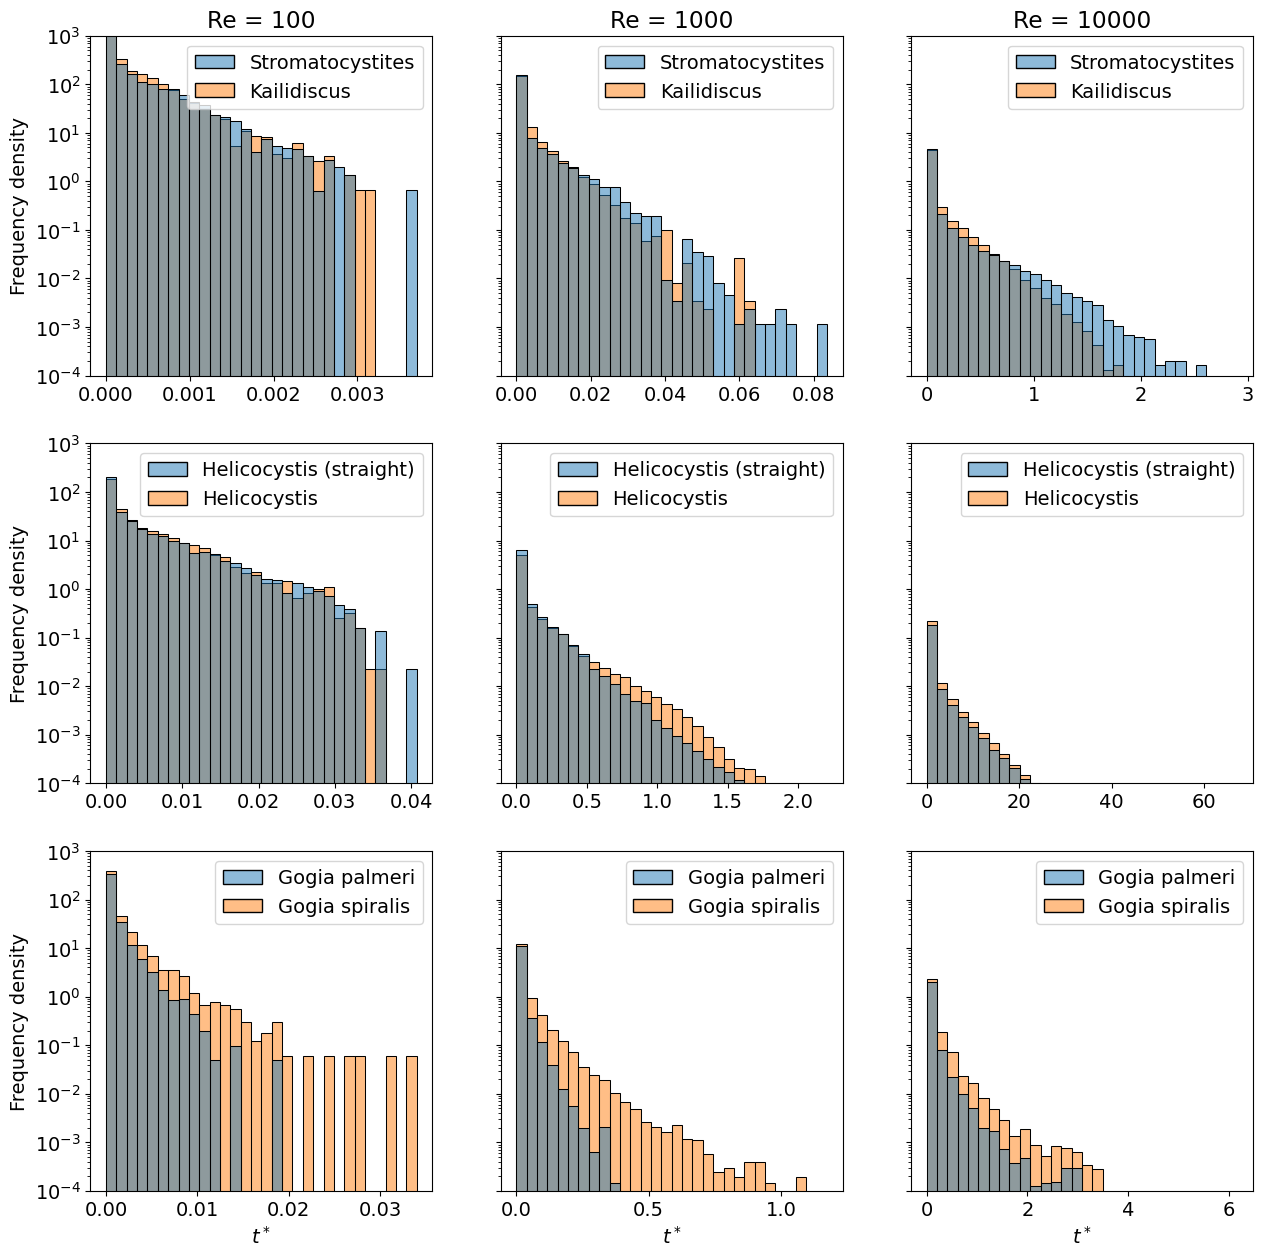

In [5]:
# 2. Fit Gamma distribution to data
# floc=0 often helps if data is non-negative
#shape, loc, scale = stats.gamma.fit(edrio_data[4], floc=0)
# 4. Plot fitted PDF
#x = np.linspace(0, max(edrio_data[4]), 100)
#fitted_pdf = stats.gamma.pdf(x, shape, loc, scale)
plt.rcParams.update({'font.size': 14})
fig, axs = plt.subplots(3, 3, figsize=(15, 15), sharey=True)
s = []
h = []
for i in range(3): #5
    s.append(sns.histplot(data=edrio_data[i],
                stat='density',
                common_norm=True, 
                #multiple='dodge', 
                bins=30, 
                #ax=ax#,
                #log_scale=True,
                #kde=True,
                ax = axs[0,i]
                ))
    axs[0,i].set_yscale('log')
    axs[0,i].set_ylabel('Frequency density')
    axs[0,i].set_ylim(1E-4, 1E3)

    h.append(sns.histplot(data=helico_data[i],
                stat='density',
                common_norm=True, 
                #multiple='dodge', 
                bins=30, 
                #ax=ax#,
                #log_scale=True,
                #kde=True,
                ax = axs[1,i]
                ))
    axs[1,i].set_ylabel('Frequency density')
    axs[0,i].set_ylim(1E-4, 1E3)   

    sns.histplot(data=gogia_data[i],
                stat='density',
                common_norm=True, 
                #multiple='dodge', 
                bins=30, 
                #ax=ax#,
                #log_scale=True,
                #kde=True,
                ax = axs[2,i]
                )
    axs[2,i].set_xlabel(r'$t^*$')
    axs[2,i].set_ylabel('Frequency density')


x_10000 = np.arange(0.5, 2, 0.05)
x_5000 = np.arange(0.2, 0.8, 0.01)
a_stromat = 2.4
b_stromat = 0.1
y_stromat = b_stromat * np.exp(-a_stromat*x_10000)
a_kaili = 4.8
b_kaili = 0.5
y_kaili = b_kaili * np.exp(-a_kaili*x_10000)

legend = axs[0,2].get_legend()
histplot_handles = legend.legend_handles
print(histplot_handles)

axs[0,0].set_title('Re = 100')
axs[0,1].set_title('Re = 1000')
axs[0,2].set_title('Re = 10000')
#s[2]._egend.set(visible=False)
#l1 = axs[0,2].plot(x_10000,y_stromat, color='blue', linestyle='--', label=r'$\propto e^{-2.4t^*}$')
#l1_handle = l1.get_legend().legend_handles[0]
#l2 = axs[0,2].plot(x_10000,y_kaili, color='orange', linestyle='--', label=r'$\propto e^{-4.8t^*}$')
#l2_handle = l2.get_legend().legend_handles[0]
#handles = histplot_handles + [l1_handle, l2_handle]
#axs[0,2].legend(handles=[l1,l2]+histplot_handles, labels=['label1','label2']+['cat_label1','cat_label2'])
#axs[0,2].legend(handles=handles + [l1, l2], labels=['label1','label2', 'label3', 'label4'])

#axs[3].plot(x_5000, 0.23 * np.exp(-7*x_5000), color='blue', linestyle='--', label=r'$\propto e^{-7t^*}$')
#axs[3].plot(x_5000, 1.7 * np.exp(-13*x_5000), color='orange', linestyle='--', label=r'$\propto e^{-13t^*}$')
    
#axs[4].legend()
#axs[0,2].legend()
plt.savefig('figures/tstar.pdf', bbox_inches='tight', dpi=400)


The non-dimensional residence time is lower in the spiral Kailidiscus so we could say that feeding performance way lower than in Stromatocystites

### Helicocystis:
Diameter of ROI, D = 0.006 m

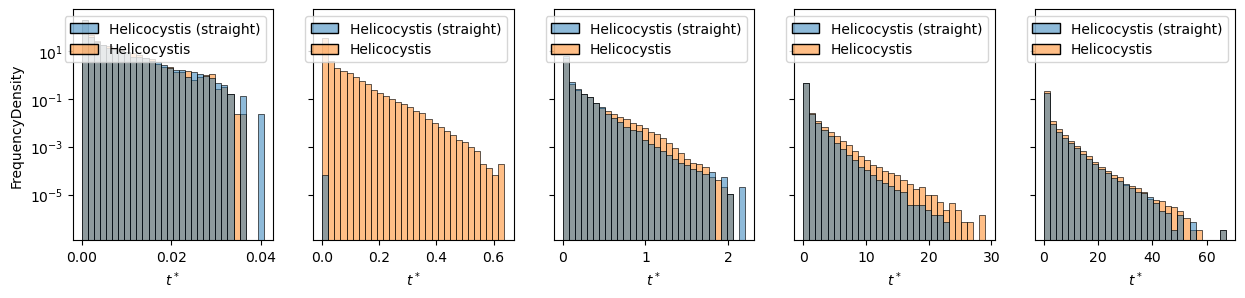

In [8]:
fig, axs = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
for i in range(5):
    sns.histplot(data=helico_data[i],
                stat='density',
                common_norm=True, 
                #multiple='dodge', 
                bins=30, 
                #ax=ax#,
                #log_scale=True,
                #kde=True,
                ax = axs[i]
                )
    axs[i].set_yscale('log')
    axs[i].set_xlabel(r'$t^*$')
    axs[i].set_ylabel('FrequencyDensity')
    #axs[i].set_ylim(1E-4, 1E3)
    #axs[i].set_xlim(0,3)
#axs[4].set_xlim(0,25)
plt.savefig('tstar_helico.pdf', bbox_inches='tight')

### Gogiids
Measured helicity at area around brachioles
Gogia spiralis: D = 0.04
Gogia palmeri: D = 0.08

In [3]:
g_pal_100 = func.calc_residence_time(par.Gogia_palmeri, 'helicity_resampled.csv', D = 0.08, Re=100)
g_pal_500 = func.calc_residence_time(par.Gogia_palmeri, 'helicity_resampled.csv', D = 0.08, Re=500)
g_pal_1000 = func.calc_residence_time(par.Gogia_palmeri, 'helicity_resampled.csv', D = 0.08, Re=1000)
g_pal_5000 = func.calc_residence_time(par.Gogia_palmeri, 'helicity_resampled.csv', D = 0.08, Re=5000)
g_pal_10000 = func.calc_residence_time(par.Gogia_palmeri, 'helicity_resampled.csv', D = 0.08, Re=10000)
g_pal_data = [g_pal_100, g_pal_500, g_pal_1000, g_pal_5000, g_pal_10000]

g_sp_100 = func.calc_residence_time(par.Gogia_spiralis, 'helicity_resampled.csv', D = 0.04, Re=100)
g_sp_500 = func.calc_residence_time(par.Gogia_spiralis, 'helicity_resampled.csv', D = 0.04, Re=500)
g_sp_1000 = func.calc_residence_time(par.Gogia_spiralis, 'helicity_resampled.csv', D = 0.04, Re=1000)
g_sp_5000 = func.calc_residence_time(par.Gogia_spiralis, 'helicity_resampled.csv', D = 0.04, Re=5000)
g_sp_10000 = func.calc_residence_time(par.Gogia_spiralis, 'helicity_resampled.csv', D = 0.04, Re=10000)
g_sp_data = [g_sp_100, g_sp_500, g_sp_1000, g_sp_5000, g_sp_10000]


gogia_data = [
    {'Gogia palmeri': g_pal_data[0], 'Gogia spiralis': g_sp_data[0]},
    {'Gogia palmeri': g_pal_data[1], 'Gogia spiralis': g_sp_data[1]},
    {'Gogia palmeri': g_pal_data[2], 'Gogia spiralis': g_sp_data[2]},
    {'Gogia palmeri': g_pal_data[3], 'Gogia spiralis': g_sp_data[3]},
    {'Gogia palmeri': g_pal_data[4], 'Gogia spiralis': g_sp_data[4]}
]

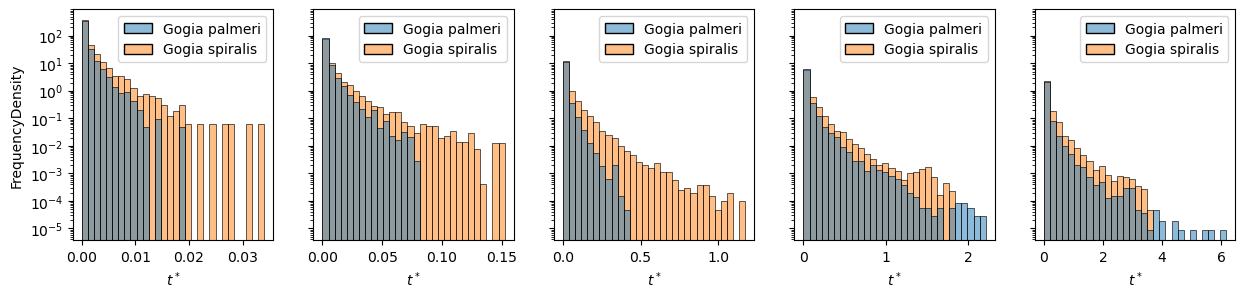

In [9]:
fig, axs = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
for i in range(5):
    sns.histplot(data=gogia_data[i],
                stat='density',
                common_norm=True, 
                #multiple='dodge', 
                bins=30, 
                #ax=ax#,
                #log_scale=True,
                #kde=True,
                ax = axs[i]
                )
    axs[i].set_yscale('log')
    axs[i].set_xlabel(r'$t^*$')
    axs[i].set_ylabel('FrequencyDensity')
    #axs[i].set_ylim(1E-4, 1E3)
    #axs[i].set_xlim(0,3)
#axs[4].set_xlim(0,25)
plt.savefig('tstar_gogia.pdf', bbox_inches='tight')

### Combined plot:

/tmp/jmcdermo_10485712/ipykernel_4144965/3221483109.py:14: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs[0].set_ylim(0, 1e2)


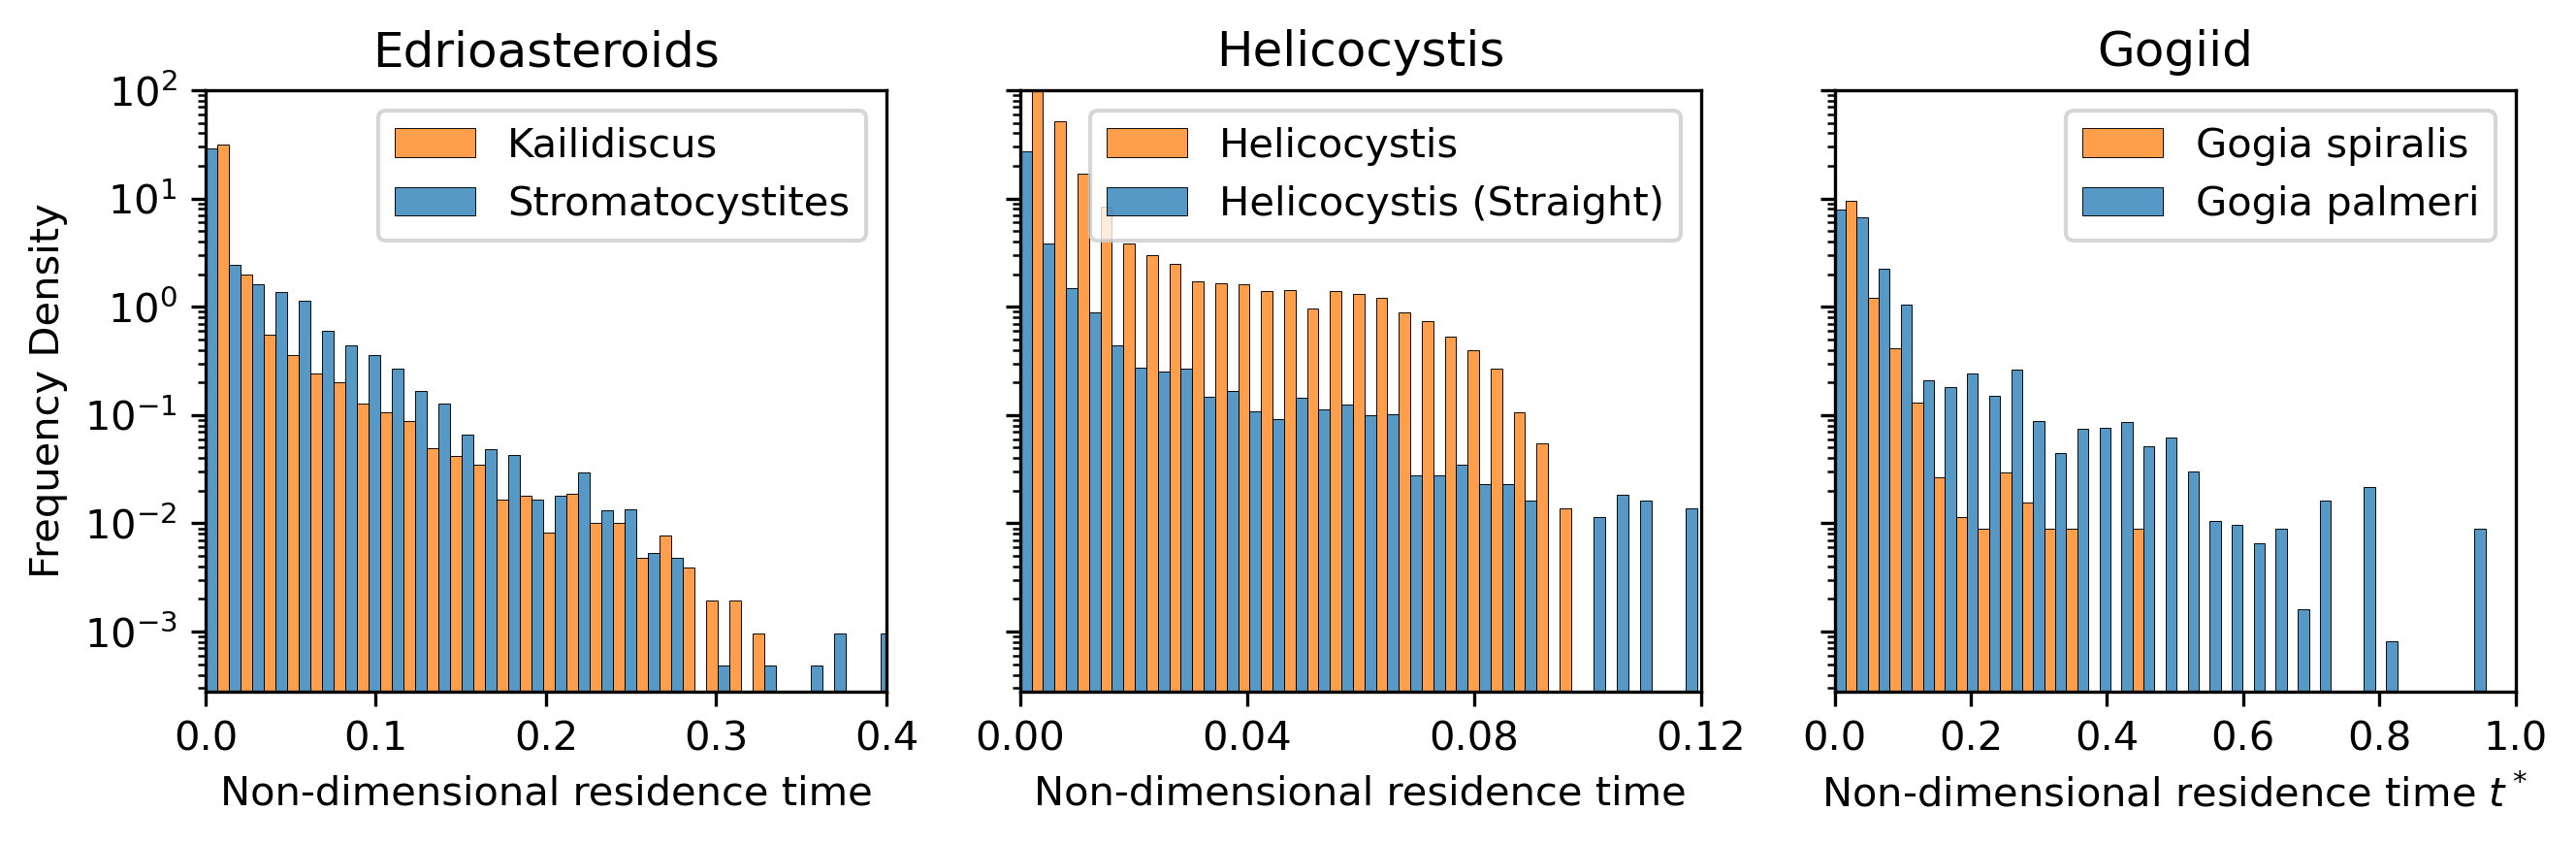

In [28]:
fig, axs = plt.subplots(1,3,figsize=(9, 3), sharey=True, dpi = 300)
sns.histplot(data=edrio_data,
            stat='density',
            common_norm=True, 
            multiple='dodge', 
            bins=30, 
            ax=axs[0],
            )
axs[0].set_yscale('log')
axs[0].set_xlabel('Non-dimensional residence time')
axs[0].set_ylabel('Frequency Density')
axs[0].legend(edrio_data)
axs[0].set_title('Edrioasteroids')
axs[0].set_ylim(0, 1e2)
axs[0].set_xlim(0, 0.4)


sns.histplot(data=helico_data,
            stat='density',
            common_norm=True, 
            multiple='dodge', 
            bins=30, 
            ax=axs[1],
            )
axs[1].set_yscale('log')
axs[1].set_xlabel('Non-dimensional residence time')
axs[1].set_ylabel('Frequency Density')
axs[1].legend(helico_data)
axs[1].set_title('Helicocystis')
axs[1].set_xticks([0, 0.04, 0.08, 0.12])
axs[1].set_xlim(0, 0.12)

sns.histplot(data=gogiid_data,
            stat='density',
            common_norm=True, 
            multiple='dodge', 
            bins=30, 
            ax=axs[2],
            )
axs[2].set_yscale('log')
axs[2].set_xlabel('Non-dimensional residence time 'r'$t^*$')
axs[2].set_ylabel('Frequency Density')
axs[2].legend(gogiid_data)
axs[2].set_title('Gogiid')
axs[2].set_xlim(0, 1)

plt.tight_layout()
#plt.savefig('residence_time.pdf', dpi=300, bbox_inches='tight')